# RF-DETR — reprodução reduzida do artigo

Notebook baseado em **RF-DETR: Neural Architecture Search for Real-Time Detection Transformers** (ICLR 2026, arXiv:2511.09554v2).

## O que será reproduzido

Esta é uma reprodução **reduzida e honesta**, adequada a uma GPU de notebook:

1. baixar um dos 100 conjuntos oficiais do RF100-VL em COCO JSON;
2. inspecionar imagens, classes e caixas;
3. ajustar um RF-DETR Nano pré-treinado com `lr=1e-4` e acumulação de gradiente;
4. medir mAP no teste;
5. medir latência com a pausa de 200 ms proposta pelo artigo para reduzir *thermal throttling*;
6. reconstruir a curva acurácia–latência da tabela do artigo.

Não reproduzimos a busca NAS completa. O apêndice avalia 6.468 configurações e estima aproximadamente **10.000 GPU-horas** (200 T4 por 48 h). Além disso, a busca NAS para novos conjuntos é oferecida na plataforma Roboflow, mas não faz parte da API local simples usada aqui.

## 1. Ambiente

In [1]:
%pip install -q "rfdetr[train]==1.8.3" "rf100vl==1.1.2" "supervision==0.29.1" pandas matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib.metadata as metadata
import json
import os
import random
import statistics
import time
from collections import defaultdict
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import supervision as sv
import torch
from PIL import Image, ImageDraw

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print({
    "device": DEVICE,
    "gpu": torch.cuda.get_device_name(0) if DEVICE == "cuda" else None,
    "torch": torch.__version__,
    "rfdetr": metadata.version("rfdetr"),
    "rf100vl": metadata.version("rf100vl"),
})

{'device': 'cuda', 'gpu': 'NVIDIA GeForce RTX 4070 Laptop GPU', 'torch': '2.13.0+cu130', 'rfdetr': '1.8.3', 'rf100vl': '1.1.2'}


## 2. Configuração do experimento

O índice escolhe um dos cem conjuntos do benchmark. Troque-o para repetir o experimento em outro domínio. Dez épocas servem para validar o pipeline; o artigo observa que conjuntos pequenos podem precisar de mais de cem épocas para convergir.

In [3]:
ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
DOWNLOAD_ROOT = ROOT / "data" / "rf100vl_subset"
OUTPUT_DIR = ROOT / "runs" / "rfdetr_nano_rf100vl"

DATASET_INDEX = 0
EPOCHS = 600
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 8  
LEARNING_RATE = 1e-4

DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert BATCH_SIZE * GRAD_ACCUM_STEPS == 16

## 3. Dataset oficial RF100-VL

In [4]:
annotation_files = list(DOWNLOAD_ROOT.rglob("_annotations.coco.json"))
if not annotation_files:
    from rf100vl import download_rf100vl_index

    api_key = os.environ.get("ROBOFLOW_API_KEY") or getpass("ROBOFLOW_API_KEY: ")
    download_rf100vl_index(
        DATASET_INDEX,
        str(DOWNLOAD_ROOT),
        model_format="coco",
        api_key=api_key,
    )
    del api_key

train_annotations = [
    path for path in DOWNLOAD_ROOT.rglob("_annotations.coco.json")
    if path.parent.name == "train"
]
assert train_annotations, f"Nenhum split COCO encontrado em {DOWNLOAD_ROOT}"
DATASET_DIR = train_annotations[0].parent.parent
print("Dataset:", DATASET_DIR)

Dataset: /home/ribeiro.alvaro/Documentos/Mestrado/Repositories/alvaro-ribeiro-985-tp558/seminar1/notebooks/data/rf100vl_subset


In [5]:
def load_split(split):
    annotation_path = DATASET_DIR / split / "_annotations.coco.json"
    if not annotation_path.exists():
        return None
    with annotation_path.open(encoding="utf-8") as file:
        return json.load(file)

rows = []
for split in ("train", "valid", "test"):
    coco = load_split(split)
    if coco:
        rows.append({
            "split": split,
            "imagens": len(coco["images"]),
            "anotações": len(coco["annotations"]),
            "classes": len(coco["categories"]),
        })

train_coco = load_split("train")
categories = sorted(train_coco["categories"], key=lambda item: item["id"])
CLASS_NAMES = [item["name"] for item in categories]
NUM_CLASSES = len(CLASS_NAMES)
display(pd.DataFrame(rows))
print("Classes:", CLASS_NAMES)

,split,imagens,anotações,classes
0,train,828,5099,7
1,valid,236,1490,7
2,test,119,742,7


Classes: ['hammer', 'hanger bar', 'hook', 'pedestal', 'pillar', 'pillar with bracket', 'safety joint']


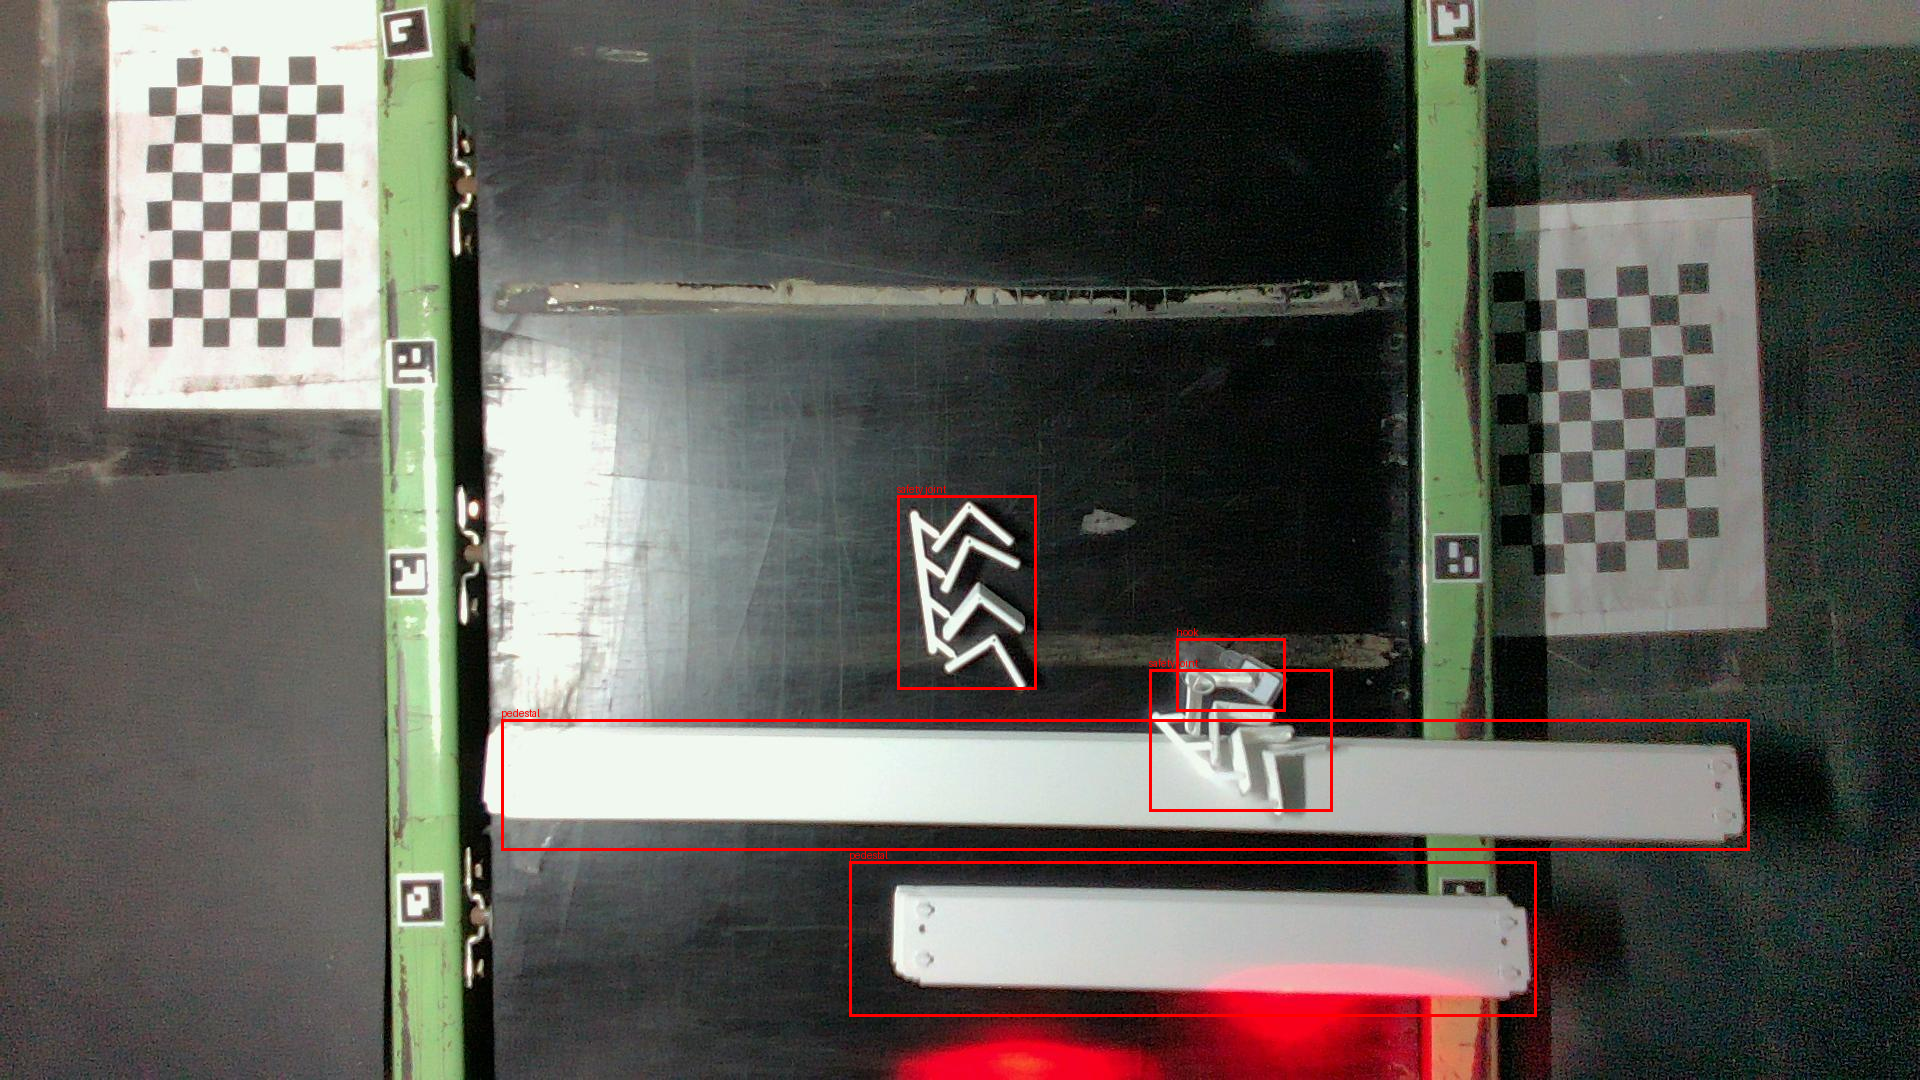

In [6]:
image_info = random.choice(train_coco["images"])
image_path = DATASET_DIR / "train" / image_info["file_name"]
if not image_path.exists():
    image_path = next((DATASET_DIR / "train").rglob(Path(image_info["file_name"]).name))

category_by_id = {item["id"]: item["name"] for item in categories}
annotations_by_image = defaultdict(list)
for annotation in train_coco["annotations"]:
    annotations_by_image[annotation["image_id"]].append(annotation)

image = Image.open(image_path).convert("RGB")
draw = ImageDraw.Draw(image)
for annotation in annotations_by_image[image_info["id"]]:
    x, y, width, height = annotation["bbox"]
    label = category_by_id[annotation["category_id"]]
    draw.rectangle((x, y, x + width, y + height), outline="red", width=3)
    draw.text((x, max(0, y - 12)), label, fill="red")
display(image)

## 4. Fine-tuning

O RF-DETR usa DINOv2 como *backbone*. Inicializamos explicitamente o número de classes para que a cabeça de classificação corresponda ao conjunto escolhido. O `lr=1e-4` vem do apêndice do artigo; EMA e acumulação de gradiente seguem a implementação oficial.

In [7]:
from rfdetr import RFDETRNano

assert DEVICE == "cuda", "Treinamento em CPU é impraticável; selecione um runtime com GPU."
model = RFDETRNano(num_classes=NUM_CLASSES)
model.train(
    dataset_dir=str(DATASET_DIR),
    output_dir=str(OUTPUT_DIR),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    lr=LEARNING_RATE,
    use_ema=True,
    early_stopping=False,
    device=DEVICE,
)

Val (Epoch 600/600) — Overall Metrics              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃           mAP            ┃  mAR   ┃         F1 sweep         ┃
┡━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━╇━━━━━━━━┯━━━━━━━━┯━━━━━━━━┩
│ 50:95  │   50   │   75   │  @500  │   F1   │  Prec  │ Recall │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│ 0.6298 │ 0.9114 │ 0.7057 │ 0.7329 │ 0.9074 │ 0.9130 │ 0.9030 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┘
                 Val (Epoch 600/600) — Per-class Metrics                 
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ Class               ┃ AP 50:95 ┃     AR ┃     F1 ┃ Precision ┃ Recall ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ hammer              │   0.5993 │ 0.7337 │ 0.9438 │    0.9282 │ 0.9600 │
│ hanger bar          │   0.7239 │ 0.7667 │ 1.0000 │    1.0000 │ 1.0000 │
│ hook                │   0.3117 │ 0.4625 │ 0.7238 │    0.7755 │ 0.6786 │
│ pedestal            │   0.7564 │ 0.8618 │ 0.9459 │    0.9468 │ 0.9449 │
│ pillar              │   0.7626 │ 0.8480 │ 0.9649 │    0.9667 │ 0.9631 │
│ pillar with bracket │   0.6700 │ 0.7662 │ 0.9091 │    0.9220 │ 0.8966 │
│ safety joint        │   0.5847 │ 0.6917 │ 0.8645 │    0.8517 │ 0.8777 │
└─────────────────────┴──────────┴────────┴────────┴───────────┴────────┘

`Trainer.fit` stopped: `max_epochs=600` reached.


[2026-08-17 04:55:54] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.6552, ema=0.6613)


Se o runtime reiniciar após o treinamento, recarregue o melhor artefato com a célula abaixo. Caso contrário, ela apenas mantém o modelo já treinado em memória.

In [8]:
checkpoint = OUTPUT_DIR / "checkpoint_best_total.pth"
if "model" not in globals():
    assert checkpoint.exists(), "Execute primeiro a célula de treinamento."
    model = RFDETRNano(num_classes=NUM_CLASSES, pretrain_weights=str(checkpoint))
print("Checkpoint:", checkpoint)

Checkpoint: /home/ribeiro.alvaro/Documentos/Mestrado/Repositories/alvaro-ribeiro-985-tp558/seminar1/notebooks/runs/rfdetr_nano_rf100vl/checkpoint_best_total.pth


## 5. Avaliação COCO

In [9]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from tqdm.auto import tqdm

evaluation_split = "test" if (DATASET_DIR / "test" / "_annotations.coco.json").exists() else "valid"
evaluation_dir = DATASET_DIR / evaluation_split
coco_gt = COCO(str(evaluation_dir / "_annotations.coco.json"))
class_to_category = dict(enumerate(sorted(coco_gt.getCatIds())))
predictions = []

for image_info in tqdm(coco_gt.dataset["images"], desc=f"Avaliando {evaluation_split}"):
    image_path = evaluation_dir / image_info["file_name"]
    if not image_path.exists():
        image_path = next(evaluation_dir.rglob(Path(image_info["file_name"]).name))
    detections = model.predict(str(image_path), threshold=0.001)
    for box, score, class_id in zip(detections.xyxy, detections.confidence, detections.class_id):
        x1, y1, x2, y2 = map(float, box)
        class_id = int(class_id)
        if class_id not in class_to_category:
            continue
        predictions.append({
            "image_id": image_info["id"],
            "category_id": class_to_category[class_id],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": float(score),
        })

assert predictions, "O modelo não gerou predições para a avaliação."
coco_dt = coco_gt.loadRes(predictions)
evaluator = COCOeval(coco_gt, coco_dt, iouType="bbox")
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()
metrics = {
    "AP_50_95": evaluator.stats[0],
    "AP_50": evaluator.stats[1],
    "AP_75": evaluator.stats[2],
    "AR_100": evaluator.stats[8],
}
display(pd.Series(metrics, name="valor").to_frame())

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Avaliando test: 100%|██████████| 119/119 [00:05<00:00, 22.00it/s]


Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.52s).
Accumulating evaluation results...
DONE (t=0.12s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.602
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.904
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.680
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.262
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.607
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.555
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.700
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.733
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

,valor
AP_50_95,0.602446
AP_50,0.903999
AP_75,0.679874
AR_100,0.732742


## 6. Predição e latência

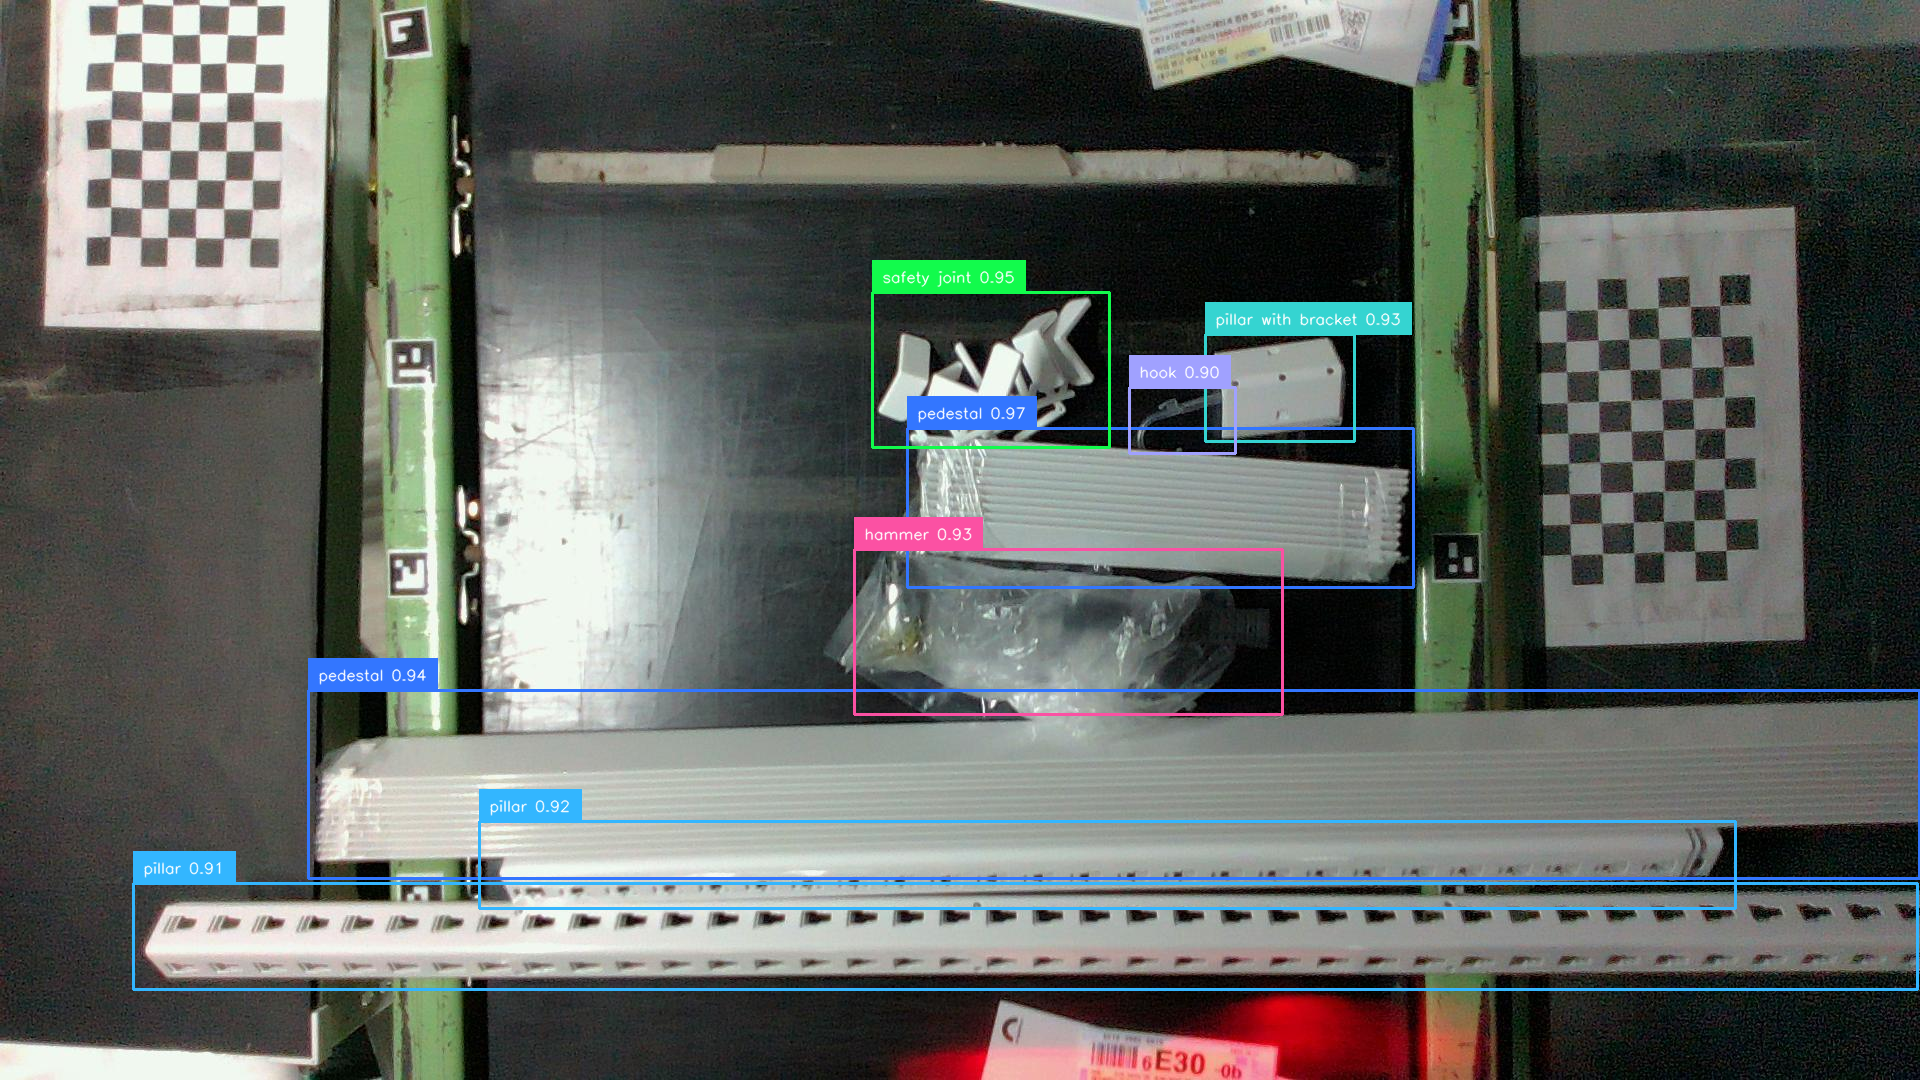

In [10]:
test_dir = DATASET_DIR / ("test" if (DATASET_DIR / "test").exists() else "valid")
sample_path = next(
    path for path in test_dir.rglob("*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)
sample = Image.open(sample_path).convert("RGB")
detections = model.predict(sample, threshold=0.3)

detected_names = detections.data.get("class_name")
if detected_names is None:
    detected_names = [CLASS_NAMES[index] for index in detections.class_id]
labels = [
    f"{name} {confidence:.2f}"
    for name, confidence in zip(detected_names, detections.confidence)
]
scene = np.asarray(sample).copy()
scene = sv.BoxAnnotator().annotate(scene=scene, detections=detections)
scene = sv.LabelAnnotator().annotate(scene=scene, detections=detections, labels=labels)
display(Image.fromarray(scene))

In [11]:
def synchronize():
    if DEVICE == "cuda":
        torch.cuda.synchronize()

for _ in range(10):
    model.predict(sample, threshold=0.3)
synchronize()

latencies_ms = []
for _ in range(50):
    synchronize()
    start = time.perf_counter()
    model.predict(sample, threshold=0.3)
    synchronize()
    latencies_ms.append((time.perf_counter() - start) * 1_000)
    time.sleep(0.2)

latency_summary = {
    "mediana_ms": statistics.median(latencies_ms),
    "media_ms": statistics.mean(latencies_ms),
    "desvio_padrao_ms": statistics.stdev(latencies_ms),
    "p95_ms": float(np.percentile(latencies_ms, 95)),
}
latency_summary

{'mediana_ms': 30.716702500285464,
 'media_ms': 32.682436640243395,
 'desvio_padrao_ms': 9.713482737994623,
 'p95_ms': 35.86340814908908}

## 7. Curva de Pareto publicada

Os pontos abaixo são os valores de detecção no COCO reportados nas Tabelas 2 e 12 do PDF v2, não resultados medidos por este notebook. Eles servem para conferir visualmente a principal conclusão do artigo: variantes maiores aumentam a AP em troca de latência.

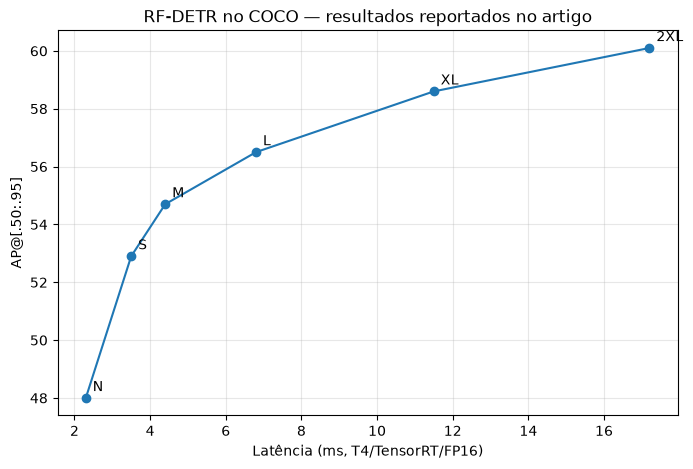

,modelo,latencia_ms_T4_TensorRT_FP16,COCO_AP_50_95
0,N,2.3,48.0
1,S,3.5,52.9
2,M,4.4,54.7
3,L,6.8,56.5
4,XL,11.5,58.6
5,2XL,17.2,60.1


In [12]:
paper_results = pd.DataFrame({
    "modelo": ["N", "S", "M", "L", "XL", "2XL"],
    "latencia_ms_T4_TensorRT_FP16": [2.3, 3.5, 4.4, 6.8, 11.5, 17.2],
    "COCO_AP_50_95": [48.0, 52.9, 54.7, 56.5, 58.6, 60.1],
})

ax = paper_results.plot(
    x="latencia_ms_T4_TensorRT_FP16",
    y="COCO_AP_50_95",
    marker="o",
    legend=False,
    figsize=(8, 5),
)
for row in paper_results.itertuples():
    ax.annotate(row.modelo, (row.latencia_ms_T4_TensorRT_FP16, row.COCO_AP_50_95), xytext=(5, 5), textcoords="offset points")
ax.set(title="RF-DETR no COCO — resultados reportados no artigo", xlabel="Latência (ms, T4/TensorRT/FP16)", ylabel="AP@[.50:.95]")
ax.grid(alpha=0.3)
plt.show()
display(paper_results)

## 8. Registro do experimento

In [13]:
def json_number(value):
    if hasattr(value, "item"):
        value = value.item()
    return float(value) if isinstance(value, (int, float)) else str(value)

experiment = {
    "paper": "arXiv:2511.09554v2",
    "dataset_index": DATASET_INDEX,
    "dataset_dir": str(DATASET_DIR),
    "classes": CLASS_NAMES,
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "lr": LEARNING_RATE,
    "gpu": torch.cuda.get_device_name(0),
    "versions": {name: metadata.version(name) for name in ("rfdetr", "rf100vl", "supervision")},
    "metrics": {key: json_number(value) for key, value in metrics.items()},
    "latency_pytorch_end_to_end": latency_summary,
}
with (OUTPUT_DIR / "experiment.json").open("w", encoding="utf-8") as file:
    json.dump(experiment, file, ensure_ascii=False, indent=2)
print(OUTPUT_DIR / "experiment.json")

/home/ribeiro.alvaro/Documentos/Mestrado/Repositories/alvaro-ribeiro-985-tp558/seminar1/notebooks/runs/rfdetr_nano_rf100vl/experiment.json



## Análise dos resultados

**Dataset:** [RF100-VL — Construction Items](https://universe.roboflow.com/rf100-vl/-grccs-yi3bi-sge1z-anexl-hayl)  
**Modelo:** RF-DETR Nano · **Épocas:** 600  
**GPU:** NVIDIA GeForce RTX 4070 Laptop GPU · **Classes:** 7


,Resultado
AP@[.50:.95] (%),60.24
AP50 (%),90.40
AP75 (%),67.99
AR@100 (%),73.27


,Desempenho
Latência mediana (ms),30.72
Latência média (ms),32.68
FPS aproximado,32.56


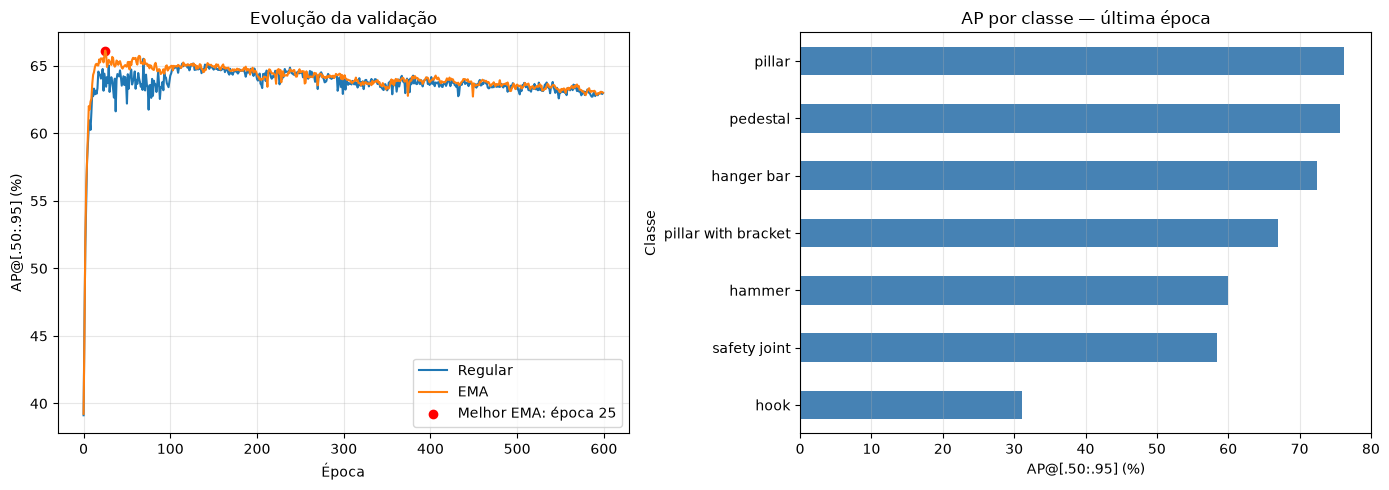

,AP validação (%),Anotações validação
hook,31.17,168
safety joint,58.47,229
hammer,59.93,175
pillar with bracket,67.00,145
hanger bar,72.39,12
pedestal,75.64,490
pillar,76.26,271



### Interpretação

- A melhor validação EMA foi **66.13%**
  na época **25**.
- Ao final das 600 épocas, a EMA caiu **3.12 p.p.**,
  indicando saturação e possível sobreajuste.
- O teste alcançou **60.24% AP**.
- A diferença de **22.41 p.p.** entre AP50 e AP75 indica
  boa detecção dos objetos, mas menor precisão das caixas em IoUs rigorosos.
- A classe mais difícil na última validação foi **hook**.
- A inferência atingiu aproximadamente **32.6 FPS** em PyTorch.
  Esse número não é diretamente comparável ao TensorRT FP16 do artigo.


In [14]:
from collections import Counter
from IPython.display import Markdown, display
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

DATASET_URL = (
    "https://universe.roboflow.com/"
    "rf100-vl/-grccs-yi3bi-sge1z-anexl-hayl"
)

run_dir = Path(OUTPUT_DIR)
results = json.loads((run_dir / "experiment.json").read_text(encoding="utf-8"))
history = pd.read_csv(run_dir / "metrics.csv")

validation = (
    history.dropna(subset=["val/mAP_50_95"])
    .sort_values("epoch")
    .copy()
)
ema_validation = validation.dropna(subset=["val/ema_mAP_50_95"])

best_regular = validation.loc[validation["val/mAP_50_95"].idxmax()]
best_ema = ema_validation.loc[ema_validation["val/ema_mAP_50_95"].idxmax()]
last = validation.iloc[-1]

test_metrics = pd.Series(
    {
        "AP@[.50:.95] (%)": results["metrics"]["AP_50_95"] * 100,
        "AP50 (%)": results["metrics"]["AP_50"] * 100,
        "AP75 (%)": results["metrics"]["AP_75"] * 100,
        "AR@100 (%)": results["metrics"]["AR_100"] * 100,
    },
    name="Resultado",
).to_frame()

latency = results["latency_pytorch_end_to_end"]
median_ms = latency["mediana_ms"]
fps = 1000 / median_ms

# AP por classe na última época de validação
ap_by_class = {
    column.removeprefix("val/AP/"): last[column] * 100
    for column in validation.columns
    if column.startswith("val/AP/")
}

valid_coco = json.loads(
    (Path(results["dataset_dir"]) / "valid" / "_annotations.coco.json")
    .read_text(encoding="utf-8")
)
class_names = {
    category["id"]: category["name"]
    for category in valid_coco["categories"]
}
annotation_counts = Counter(
    annotation["category_id"]
    for annotation in valid_coco["annotations"]
)

per_class = pd.DataFrame(
    {
        "AP validação (%)": ap_by_class,
        "Anotações validação": {
            class_names[class_id]: count
            for class_id, count in annotation_counts.items()
        },
    }
).sort_values("AP validação (%)")

display(
    Markdown(
        f"""
## Análise dos resultados

**Dataset:** [RF100-VL — Construction Items]({DATASET_URL})  
**Modelo:** RF-DETR Nano · **Épocas:** {results["epochs"]}  
**GPU:** {results["gpu"]} · **Classes:** {len(results["classes"])}
"""
    )
)

display(test_metrics.round(2))
display(
    pd.Series(
        {
            "Latência mediana (ms)": median_ms,
            "Latência média (ms)": latency["media_ms"],
            "FPS aproximado": fps,
        },
        name="Desempenho",
    ).round(2).to_frame()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    validation["epoch"],
    validation["val/mAP_50_95"] * 100,
    label="Regular",
)
axes[0].plot(
    ema_validation["epoch"],
    ema_validation["val/ema_mAP_50_95"] * 100,
    label="EMA",
)
axes[0].scatter(
    best_ema["epoch"],
    best_ema["val/ema_mAP_50_95"] * 100,
    color="red",
    label=f"Melhor EMA: época {int(best_ema['epoch'])}",
)
axes[0].set(
    title="Evolução da validação",
    xlabel="Época",
    ylabel="AP@[.50:.95] (%)",
)
axes[0].grid(alpha=0.3)
axes[0].legend()

per_class["AP validação (%)"].plot.barh(
    ax=axes[1],
    color="steelblue",
)
axes[1].set(
    title="AP por classe — última época",
    xlabel="AP@[.50:.95] (%)",
    ylabel="Classe",
)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

display(per_class.round(2))

drop_after_best = (
    best_ema["val/ema_mAP_50_95"]
    - last["val/ema_mAP_50_95"]
) * 100
ap50_ap75_gap = (
    results["metrics"]["AP_50"]
    - results["metrics"]["AP_75"]
) * 100
weakest_class = per_class["AP validação (%)"].idxmin()

display(
    Markdown(
        f"""
### Interpretação

- A melhor validação EMA foi **{best_ema["val/ema_mAP_50_95"]:.2%}**
  na época **{int(best_ema["epoch"])}**.
- Ao final das 600 épocas, a EMA caiu **{drop_after_best:.2f} p.p.**,
  indicando saturação e possível sobreajuste.
- O teste alcançou **{results["metrics"]["AP_50_95"]:.2%} AP**.
- A diferença de **{ap50_ap75_gap:.2f} p.p.** entre AP50 e AP75 indica
  boa detecção dos objetos, mas menor precisão das caixas em IoUs rigorosos.
- A classe mais difícil na última validação foi **{weakest_class}**.
- A inferência atingiu aproximadamente **{fps:.1f} FPS** em PyTorch.
  Esse número não é diretamente comparável ao TensorRT FP16 do artigo.
"""
    )
)

## Resultados reportados no artigo

Os autores avaliaram o RF-DETR nos benchmarks COCO e RF100-VL, considerando a precisão média (*Average Precision*, AP) e a latência de inferência.

### Detecção de objetos no COCO

| Modelo | COCO AP | Latência |
| --- | ---: | ---: |
| RF-DETR Nano | 48,0 | 2,3 ms |
| RF-DETR Small | 52,9 | 3,5 ms |
| RF-DETR Medium | 54,7 | 4,4 ms |
| RF-DETR 2XL | 60,1 | 17,2 ms |

O RF-DETR Nano supera o D-FINE Nano em aproximadamente 5 AP com latência semelhante. Segundo os autores, o RF-DETR 2XL é o primeiro detector em tempo real apresentado no estudo a ultrapassar 60 AP no COCO.

### Generalização no RF100-VL

O RF100-VL reúne 100 conjuntos de detecção provenientes de diferentes domínios. Nesse benchmark, o RF-DETR 2XL alcança 63,3 AP e chega a 63,5 AP após o ajuste fino, com latência de 15,6 ms. No mesmo protocolo, o GroundingDINO Tiny e o LLMDet Tiny obtêm 62,3 AP e aproximadamente 309 ms. Assim, o RF-DETR apresenta precisão ligeiramente superior e inferência cerca de 20 vezes mais rápida.

### Segmentação de instâncias

Na segmentação COCO, o RF-DETR-Seg Nano alcança 40,3 AP em 3,4 ms. O modelo supera as variantes YOLO apresentadas pelos autores e obtém ganho de 5,4 AP sobre o FastInst, com inferência aproximadamente dez vezes mais rápida.

### Impacto da NAS

Os experimentos de ablação mostram ganhos progressivos com a adoção do DINOv2, do pré-treinamento no Objects365 e da busca de arquitetura com pesos compartilhados. A configuração final apresenta ganho aproximado de 2 AP em relação ao LW-DETR, sem aumento relevante de latência.

> **Observação:** as latências do artigo foram medidas em uma NVIDIA T4 com TensorRT FP16. Portanto, esses valores não devem ser comparados diretamente aos resultados da nossa reprodução, executada em PyTorch em uma RTX 4070 Laptop.

**Referência:** [RF-DETR: Neural Architecture Search for Real-Time Detection Transformers](https://arxiv.org/abs/2511.09554)